# Recovering a TIB 

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from ga.filters.tib import (null_basis_realization, null_basis_realization_real, build_tib_from_directions, build_tib_from_directions_real,
                            mimo_poles_to_ir, krylov_basis, poles_chebyshev_roots)
from ga.reducers.hankel import msvdreduce, msvdreduce_fixed, msvdreduce_eig, blkhankel, lschur, msvdreduce_fast, msvdreduce_complex

## A Known MIMO TIB system 

In [2]:
rng = np.random.default_rng(3)
n, q, p, L = 10, 5, 3, 200                         # order, inputs, outputs, IR lags
poles0 = poles_chebyshev_roots(n, 0.0, 0.85)            # real, distinct poles
V0 = rng.standard_normal((q, n)); V0 /= np.linalg.norm(V0, axis=0)   # null vectors
C0 = rng.standard_normal((p, n))

sys0 = null_basis_realization(poles0, V0)
A0 = np.real(sys0.A(dense=True)); B0 = np.real(sys0.B(dense=True))
ir0 = np.real(mimo_poles_to_ir(poles0, V0, C0, L))      # (p, q, L) -- the "data"

print(f"order n={n}, inputs q={q}, outputs p={p}, IR lags L={L}")
print(f"TIB balance |A A^T + B B^T - I| = {np.max(np.abs(A0@A0.T + B0@B0.T - np.eye(n))):.1e}")

order n=10, inputs q=5, outputs p=3, IR lags L=200
TIB balance |A A^T + B B^T - I| = 2.2e-16


## Visualizing the impulse response  `h[out, in](lag)`

The IR is a transfer-function matrix: 3 outputs × 5 inputs = 15 SISO curves over 200 lags.
- **Grid**: rows = outputs, cols = inputs (first ~60 lags, since it decays fast). Set `sharey=False` if small channels get squashed.
- **Energy decay** `‖h(τ)‖_F`: overall memory / time-scales — confirms the IR has died out within `L` before feeding it to the reducer.

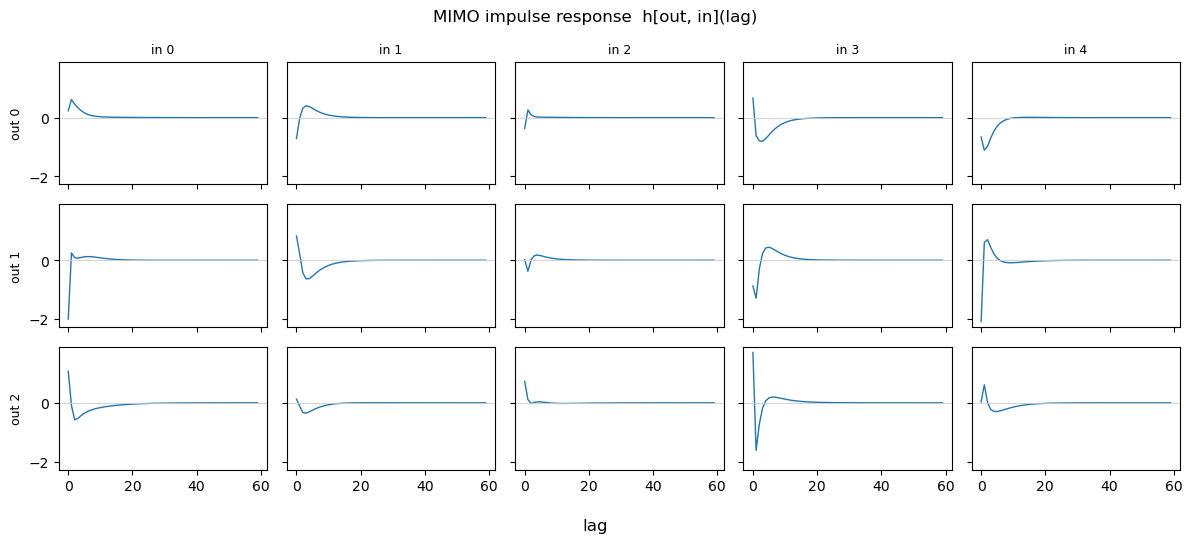

In [3]:
p, q, L = ir0.shape
show = min(60, L)                         # IR decays fast; show the first ~60 lags
fig, axes = plt.subplots(p, q, figsize=(2.4 * q, 1.8 * p), sharex=True, sharey=True)
for i in range(p):
    for j in range(q):
        ax = axes[i, j]
        ax.plot(np.arange(show), ir0[i, j, :show], lw=1)
        ax.axhline(0, color="0.8", lw=0.6)
        if i == 0:
            ax.set_title(f"in {j}", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"out {i}", fontsize=9)
fig.supxlabel("lag")
fig.suptitle("MIMO impulse response  h[out, in](lag)")
fig.tight_layout()
plt.show()

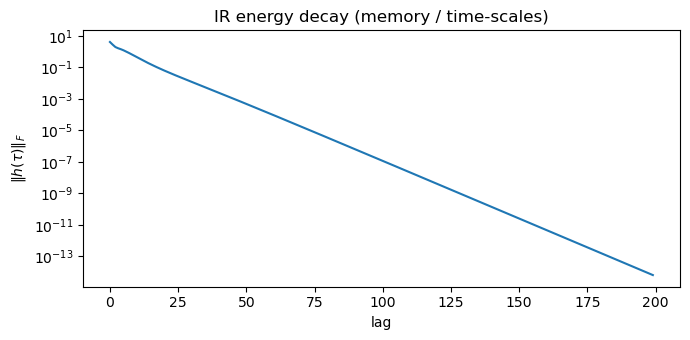

In [4]:
energy = np.linalg.norm(ir0, axis=(0, 1))      # ||h(tau)||_F per lag
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(energy)
ax.set_xlabel("lag")
ax.set_ylabel(r"$\|h(\tau)\|_F$")
ax.set_title("IR energy decay (memory / time-scales)")
fig.tight_layout()
plt.show()

In [5]:
sys, C = msvdreduce_complex(ir0, n)

In [6]:
np.sort(sys.poles())

array([0.00523246, 0.04632223, 0.12447962, 0.23205404, 0.35851535,
       0.49148465, 0.61794596, 0.72552038, 0.80367777, 0.84476754])

In [7]:
poles0

array([0.00523246, 0.04632223, 0.12447962, 0.23205404, 0.35851535,
       0.49148465, 0.61794596, 0.72552038, 0.80367777, 0.84476754])

In [8]:
from ga.filters.tib import krylov_basis

A, B = sys.A(dense=True), sys.B(dense=True)

K = np.asarray(krylov_basis(A, B, L))           # (order, q, L) = [B, AB, A^2 B, ...]
ir_rec = np.real(np.tensordot(C, K, (-1, 0)))   # (p, q, L)  h_k = C A^k B

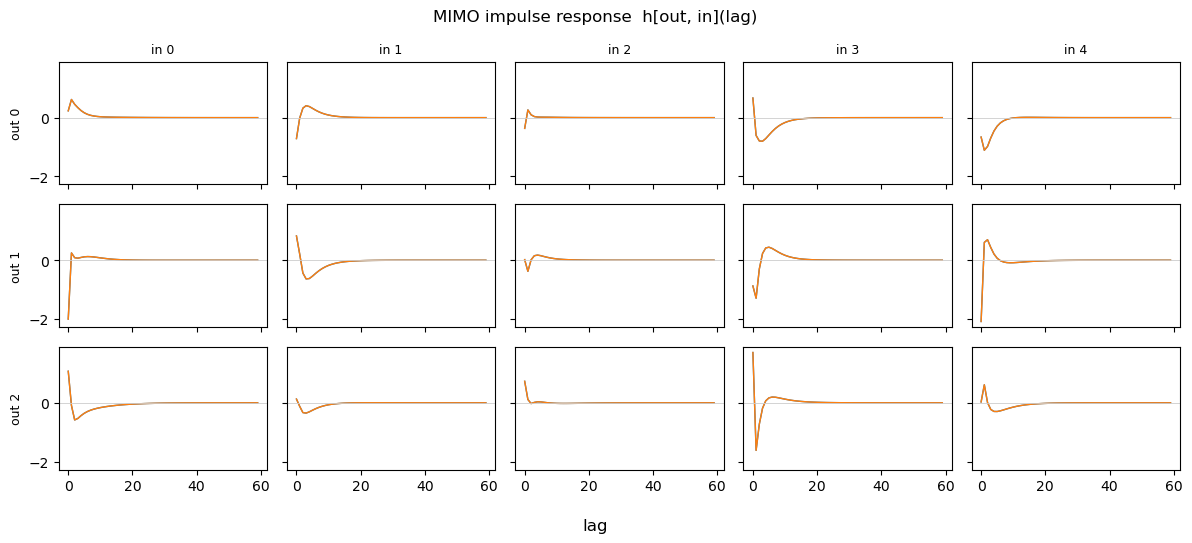

In [9]:
p, q, L = ir0.shape
show = min(60, L)                         # IR decays fast; show the first ~60 lags
fig, axes = plt.subplots(p, q, figsize=(2.4 * q, 1.8 * p), sharex=True, sharey=True)
for i in range(p):
    for j in range(q):
        ax = axes[i, j]
        ax.plot(np.arange(show), ir0[i, j, :show], lw=1)
        ax.plot(np.arange(show), ir_rec[i, j, :show], lw=1)
        ax.axhline(0, color="0.8", lw=0.6)
        if i == 0:
            ax.set_title(f"in {j}", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"out {i}", fontsize=9)
fig.supxlabel("lag")
fig.suptitle("MIMO impulse response  h[out, in](lag)")
fig.tight_layout()
plt.show()

### Quantitative check (real poles)

Pole recovery, transfer-function (IR) reconstruction, and the input-balance identity `A Aᵀ + B Bᵀ = I`.

In [10]:
A, B = sys.A(dense=True), sys.B(dense=True)
print(f"pole max|Δ| = {np.max(np.abs(np.sort(np.real(sys.poles())) - np.sort(poles0))):.1e}")
print(f"IR rel err  = {np.linalg.norm(ir_rec - ir0) / np.linalg.norm(ir0):.1e}")
print(f"balance     = {np.max(np.abs(A @ A.T + B @ B.T - np.eye(A.shape[0]))):.1e}")

pole max|Δ| = 2.7e-14
IR rel err  = 4.4e-15
balance     = 3.1e-15


## Complex-pole validation

The real-pole case above is also handled by `msvdreduce_fixed` — the point of `msvdreduce_complex` is **complex** poles. Build a real system whose poles are complex-conjugate pairs (2×2 rotation blocks), in a random basis so the block structure isn't handed to the algorithm, and check the poles come back as genuine conjugate pairs and the IR reproduces.

In [11]:
def rot(r, th):
    return r * np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])

A0c = la.block_diag(rot(0.8, 0.5), rot(0.6, 1.2), np.array([[0.3]]), rot(0.7, 0.9))
m = A0c.shape[0]
rc = np.random.default_rng(1)
T = rc.standard_normal((m, m)); A0c = T @ A0c @ la.inv(T)          # hide the block structure
B0c = rc.standard_normal((m, 3)); C0c = rc.standard_normal((2, m)); Lc = 200
irc = np.zeros((2, 3, Lc)); Ak = np.eye(m)
for kk in range(Lc):
    irc[:, :, kk] = C0c @ Ak @ B0c; Ak = Ak @ A0c

sysc, Cc = msvdreduce_complex(irc, m)
Ac, Bc = sysc.A(dense=True), sysc.B(dense=True)
rec = np.sort_complex(sysc.poles()); true = np.sort_complex(la.eigvals(A0c))
irc_rec = np.real(np.tensordot(Cc, np.asarray(krylov_basis(Ac, Bc, Lc)), (-1, 0)))

print(f"complex pole max|Δ| = {np.max(np.abs(rec - true)):.1e}   "
      f"(max|Im| = {np.max(np.abs(rec.imag)):.2f}, genuinely complex)")
print(f"IR rel err          = {np.linalg.norm(irc_rec - irc) / np.linalg.norm(irc):.1e}")
print(f"balance             = {np.max(np.abs(Ac @ Ac.T + Bc @ Bc.T - np.eye(m))):.1e}")
print(f"block-lower-tri     = {np.max(np.abs(np.triu(Ac, 2))):.1e}   (2x2 blocks on diagonal)")

complex pole max|Δ| = 4.0e-15   (max|Im| = 0.56, genuinely complex)
IR rel err          = 2.5e-15
balance             = 1.5e-15
block-lower-tri     = 5.4e-16   (2x2 blocks on diagonal)


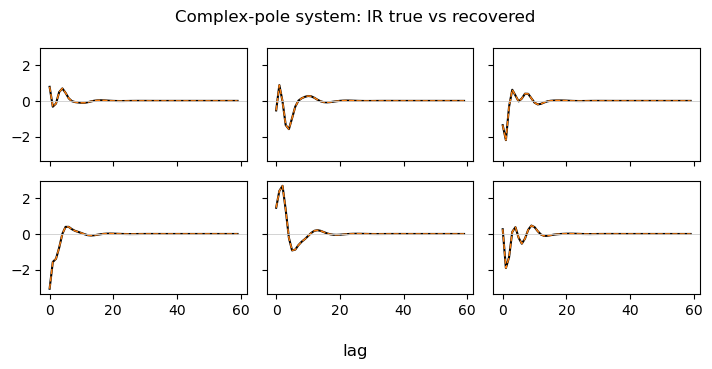

In [12]:
showc = min(60, Lc)
fig, axes = plt.subplots(2, 3, figsize=(2.4 * 3, 1.8 * 2), sharex=True, sharey=True)
for i in range(2):
    for j in range(3):
        ax = axes[i, j]
        ax.plot(np.arange(showc), irc[i, j, :showc], "k-", lw=1.5, label="true")
        ax.plot(np.arange(showc), irc_rec[i, j, :showc], "C1--", lw=1, label="recovered")
        ax.axhline(0, color="0.8", lw=0.6)
fig.supxlabel("lag"); fig.suptitle("Complex-pole system: IR true vs recovered")
fig.tight_layout(); plt.show()

## Complex poles via `null_basis_realization` (n=10, same `V0`)

Generate 10 complex poles in conjugate pairs, build the TIB system with `null_basis_realization` using the **same null vectors `V0`** (and the same `C0`), and inspect the impulse response.

In [13]:
# 1) generate 10 complex poles in conjugate pairs
g = np.random.default_rng(7)
zc = g.uniform(0.2, 0.85, 5) * np.exp(1j * g.uniform(0.2, 1.2, 5))   # 5 complex poles
poles_c = np.concatenate([zc, zc.conj()])                           # 10 poles, conjugate pairs

# 2) build the TIB system with null_basis_realization, SAME null vectors V0 (and same C0)
sys_c = null_basis_realization(poles_c, V0)
Ac, Bc = np.asarray(sys_c.A(dense=True)), np.asarray(sys_c.B(dense=True))
Kc = np.asarray(krylov_basis(Ac, Bc, L))
ir_c = np.tensordot(C0, Kc, (-1, 0))                                # impulse response

print('generated poles :', np.round(np.sort_complex(poles_c), 3))
print('eig(A) of system:', np.round(np.sort_complex(la.eigvals(Ac)), 3))
print(f'A dtype = {Ac.dtype}   IR dtype = {ir_c.dtype}   max|Im(IR)| = {np.max(np.abs(ir_c.imag)):.2e}')

generated poles : [0.188-0.291j 0.188+0.291j 0.289-0.533j 0.289+0.533j 0.31 -0.245j
 0.31 +0.245j 0.368-0.601j 0.368+0.601j 0.767-0.16j  0.767+0.16j ]
eig(A) of system: [0.188-0.291j 0.188+0.291j 0.289-0.533j 0.289+0.533j 0.31 -0.245j
 0.31 +0.245j 0.368-0.601j 0.368+0.601j 0.767-0.16j  0.767+0.16j ]
A dtype = complex128   IR dtype = complex128   max|Im(IR)| = 1.15e+00


In [14]:
poles_c

array([0.28921335+0.5328883j , 0.76674744+0.15963498j,
       0.36781466+0.60050309j, 0.18800581+0.29092294j,
       0.31020029+0.24471653j, 0.28921335-0.5328883j ,
       0.76674744-0.15963498j, 0.36781466-0.60050309j,
       0.18800581-0.29092294j, 0.31020029-0.24471653j])

## Estimate `C` from `ir0` with a complex `(A,B)`

Initialize 10 complex-conjugate poles, build `(A,B)` with `null_basis_realization` and the **same `V0`** (so `A, B` are complex), then estimate `C` from the existing real IR `ir0` by least squares (Kong eq 478, `C = ir0 · K⁺`), keeping `C` complex.

> Note: `ir0` was generated from the **real** chebyshev poles, so these different (complex) poles cannot reproduce it — `C` only sets the output mixing, not the dynamics. Expect a large residual; this is the starting point, not the end.

In [15]:
# 1) 10 complex poles in conjugate pairs
g2 = np.random.default_rng(7)
zc2 = g2.uniform(0.2, 0.85, 5) * np.exp(1j * g2.uniform(0.2, 1.2, 5))
poles_cc = np.concatenate([zc2, zc2.conj()])                       # 10 complex, conjugate pairs

# 2) complex (A, B) from null_basis_realization with the SAME null vectors V0
sys_cc = null_basis_realization(poles_cc, V0)
Acc, Bcc = np.asarray(sys_cc.A(dense=True)), np.asarray(sys_cc.B(dense=True))

# 3) estimate C from ir0  (Kong eq 478: C = IR @ pinv(Krylov)); keep C complex for complex (A,B)
Kcc = np.asarray(krylov_basis(Acc, Bcc, L))                        # (n, q, L)
C_est = ir0.reshape(p, -1) @ np.linalg.pinv(Kcc.reshape(n, -1))    # (p, n) complex
ir_fit = np.tensordot(C_est, Kcc, (-1, 0))                         # C A^k B

print(f'(A,B) complex : max|Im A| = {np.max(np.abs(Acc.imag)):.2f}')
print(f'C_est complex : max|Im C| = {np.max(np.abs(C_est.imag)):.2e}')
print(f'IR reproduction relerr    = {np.linalg.norm(ir_fit - ir0) / np.linalg.norm(ir0):.2e}')
print(f'max|Im(C A^k B)|          = {np.max(np.abs(ir_fit.imag)):.2e}')

(A,B) complex : max|Im A| = 0.60
C_est complex : max|Im C| = 7.06e-01
IR reproduction relerr    = 6.99e-01
max|Im(C A^k B)|          = 6.45e-01


## Generate a known complex-pole system with `null_basis_realization_real`

Initialize 10 known complex poles (5 conjugate pairs), build `(A, B)` with `null_basis_realization_real` and the **same `V0`** (so `A, B` come out **real**), then generate the impulse response with the given `C0`. This `(poles_true, A_true, B_true, ir_true)` is the ground-truth system to recover and compare against next.

In [16]:
# 1) known complex poles: 5 conjugate pairs (n = 10, matches V0 / C0)
gg = np.random.default_rng(11)
mags = gg.uniform(0.30, 0.85, 5); angs = gg.uniform(0.20, 1.20, 5)
poles_true = np.array([z for m, a in zip(mags, angs)
                       for z in (m*np.exp(1j*a), m*np.exp(-1j*a))])   # 10 poles, conjugate pairs

# 2) build (A, B) with null_basis_realization_real using the SAME V0  -> real A, B
sys_true = null_basis_realization_real(poles_true, V0)
A_true = np.asarray(sys_true.A(dense=True))
B_true = np.asarray(sys_true.B(dense=True))

# 3) impulse response from this (A, B) using the given C0
ir_true = np.real(np.tensordot(C0, np.asarray(krylov_basis(A_true, B_true, L)), (-1, 0)))

print('poles (5 conjugate pairs):\n', np.round(np.sort_complex(poles_true), 3))
print(f'A, B real?  max|Im A| = {np.max(np.abs(A_true.imag)) if np.iscomplexobj(A_true) else 0:.0e}, '
      f'max|Im B| = {np.max(np.abs(B_true.imag)) if np.iscomplexobj(B_true) else 0:.0e}')
print(f'eig(A) == poles?  max|d| = '
      f'{np.max(np.abs(np.sort_complex(la.eigvals(A_true)) - np.sort_complex(poles_true))):.1e}')
print(f'IR real?  max|Im(ir)| = {np.max(np.abs(np.imag(ir_true))):.0e}   shape = {ir_true.shape}')

poles (5 conjugate pairs):
 [0.129-0.288j 0.129+0.288j 0.159-0.335j 0.159+0.335j 0.26 -0.279j
 0.26 +0.279j 0.554-0.153j 0.554+0.153j 0.597-0.204j 0.597+0.204j]
A, B real?  max|Im A| = 0e+00, max|Im B| = 0e+00
eig(A) == poles?  max|d| = 4.3e-15
IR real?  max|Im(ir)| = 0e+00   shape = (3, 5, 200)


In [17]:
poles_true

array([0.15876815+0.33499441j, 0.15876815-0.33499441j,
       0.55372097+0.15349753j, 0.55372097-0.15349753j,
       0.5968325 +0.20427924j, 0.5968325 -0.20427924j,
       0.12947335+0.28801562j, 0.12947335-0.28801562j,
       0.25964577+0.27931886j, 0.25964577-0.27931886j])

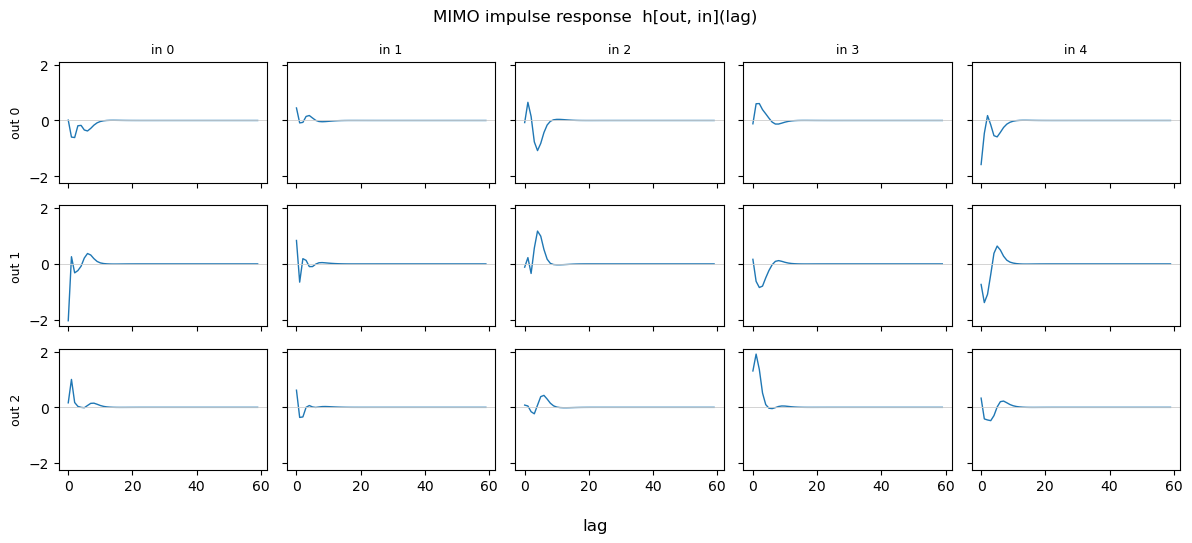

In [18]:
p, q, L = ir0.shape
show = min(60, L)                         # IR decays fast; show the first ~60 lags
fig, axes = plt.subplots(p, q, figsize=(2.4 * q, 1.8 * p), sharex=True, sharey=True)
for i in range(p):
    for j in range(q):
        ax = axes[i, j]
        ax.plot(np.arange(show), ir_true[i, j, :show], lw=1)
        ax.axhline(0, color="0.8", lw=0.6)
        if i == 0:
            ax.set_title(f"in {j}", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"out {i}", fontsize=9)
fig.supxlabel("lag")
fig.suptitle("MIMO impulse response  h[out, in](lag)")
fig.tight_layout()
plt.show()

In [19]:
print(f"TIB balance |A A^T + B B^T - I| = {np.max(np.abs(A_true@A_true.T + B_true@B_true.T - np.eye(n))):.1e}")

TIB balance |A A^T + B B^T - I| = 4.5e-16


## Reduction: recover poles (and null vectors) from `ir_true`

Apply the MIMO Hankel-SVD reduction to `ir_true`. `msvdreduce_fixed` reads the poles off the **real-Schur diagonal**, so it loses the imaginary part of each conjugate pair (returns only the real parts); `msvdreduce_eig` reads the **complex-Schur diagonal** (the eigenvalues), recovering the complex pairs exactly. Null vectors `u` are returned alongside.

In [20]:
# msvdreduce_fixed reads the real-Schur DIAGONAL -> loses Im for complex pairs
w_fixed, u_fixed = msvdreduce_fixed(ir_true, n)
# msvdreduce_eig reads the COMPLEX-Schur diagonal (eigenvalues) -> recovers complex pairs
w_eig, u_eig = msvdreduce_eig(ir_true, n)

# sort-independent pole error (np.sort_complex flips within-pair order on tiny real-part diffs)
def pole_err(w, ref):
    key = lambda z: (round(float(z.real), 9), round(float(z.imag), 9))
    return np.max(np.abs(np.array(sorted(w, key=key)) - np.array(sorted(ref, key=key))))

print('true poles      :', np.round(np.sort_complex(poles_true), 3))
print('msvdreduce_fixed:', np.round(np.sort_complex(w_fixed), 3))
print(f'  -> pole error = {pole_err(w_fixed, poles_true):.2f}   (drops Im: real-Schur diagonal)')
print('msvdreduce_eig  :', np.round(np.sort_complex(w_eig), 3))
print(f'  -> pole error = {pole_err(w_eig, poles_true):.1e}   (recovered: complex-Schur eigenvalues)')
print(f'\nnull vectors u (msvdreduce_eig): shape {u_eig.shape}, '
      f'unit-norm columns? {np.allclose(np.linalg.norm(u_eig, axis=0), 1)}')

true poles      : [0.129-0.288j 0.129+0.288j 0.159-0.335j 0.159+0.335j 0.26 -0.279j
 0.26 +0.279j 0.554-0.153j 0.554+0.153j 0.597-0.204j 0.597+0.204j]
msvdreduce_fixed: [0.129+0.j 0.129+0.j 0.159+0.j 0.159+0.j 0.26 +0.j 0.26 +0.j 0.554+0.j
 0.554+0.j 0.597+0.j 0.597+0.j]
  -> pole error = 0.33   (drops Im: real-Schur diagonal)
msvdreduce_eig  : [0.129+0.288j 0.129-0.288j 0.159-0.335j 0.159+0.335j 0.26 +0.279j
 0.26 -0.279j 0.554-0.153j 0.554+0.153j 0.597-0.204j 0.597+0.204j]
  -> pole error = 2.9e-14   (recovered: complex-Schur eigenvalues)

null vectors u (msvdreduce_eig): shape (5, 10), unit-norm columns? True


## Full-order model reduction with `msvdreduce_eig`

Run `msvdreduce_eig` at **full order** (`order = n = 10`) on `ir_true`: recover the `(poles, null vectors)`, rebuild the real TIB system with `build_tib_from_directions_real` (magnitude + rotation), and check that the poles round-trip.

In [21]:
order = n                                              # full order (no truncation)
w_rec, u_rec = msvdreduce_eig(ir_true, order)          # recover poles (eigenvalues) + null vectors
sys_rec = build_tib_from_directions_real(w_rec, u_rec) # rebuild real TIB (rotation trick)
A_rec = np.asarray(sys_rec.A(dense=True))

print('true poles            :', np.round(np.sort_complex(poles_true), 3))
print('recovered poles       :', np.round(np.sort_complex(w_rec), 3))
print('reconstructed eig(A)  :', np.round(np.sort_complex(la.eigvals(A_rec)), 3))
print(f'\nrecovered A real? max|Im A| = {np.max(np.abs(A_rec.imag)) if np.iscomplexobj(A_rec) else 0:.0e}')
print(f'pole recovery error       = {pole_err(w_rec, poles_true):.1e}')
print(f'reconstruction pole error = {pole_err(la.eigvals(A_rec), poles_true):.1e}')

true poles            : [0.129-0.288j 0.129+0.288j 0.159-0.335j 0.159+0.335j 0.26 -0.279j
 0.26 +0.279j 0.554-0.153j 0.554+0.153j 0.597-0.204j 0.597+0.204j]
recovered poles       : [0.129+0.288j 0.129-0.288j 0.159-0.335j 0.159+0.335j 0.26 +0.279j
 0.26 -0.279j 0.554-0.153j 0.554+0.153j 0.597-0.204j 0.597+0.204j]
reconstructed eig(A)  : [0.129-0.288j 0.129+0.288j 0.159-0.335j 0.159+0.335j 0.26 -0.279j
 0.26 +0.279j 0.554-0.153j 0.554+0.153j 0.597-0.204j 0.597+0.204j]

recovered A real? max|Im A| = 0e+00
pole recovery error       = 2.9e-14
reconstruction pole error = 2.2e-14


In [22]:
sys_test = null_basis_realization_real(w_rec, V0)

In [23]:
A_rec = np.asarray(sys_test.A(dense=True))

In [24]:
B_rec = np.asarray(sys_test.B(dense=True))

### Reconstructed IR vs `ir_true`

Build the impulse response from the reconstructed `(A_rec, B_rec)` with the **given `C0`** and compare to `ir_true`.

In [25]:
# B_rec = np.asarray(sys_rec.B(dense=True))
ir_rec = np.real(np.tensordot(C0, np.asarray(krylov_basis(A_rec, B_rec, L)), (-1, 0)))
relerr = np.linalg.norm(ir_rec - ir_true) / np.linalg.norm(ir_true)
print(f'IR reconstruction relerr (given C0) = {relerr:.2e}')
print(f'(poles recovered to {pole_err(w_rec, poles_true):.0e}, but the null vectors are in the modal')
print(' complex-Schur frame, not the magnitude frame -> reachability differs -> IR does not match.)')

IR reconstruction relerr (given C0) = 1.17e+00
(poles recovered to 3e-14, but the null vectors are in the modal
 complex-Schur frame, not the magnitude frame -> reachability differs -> IR does not match.)


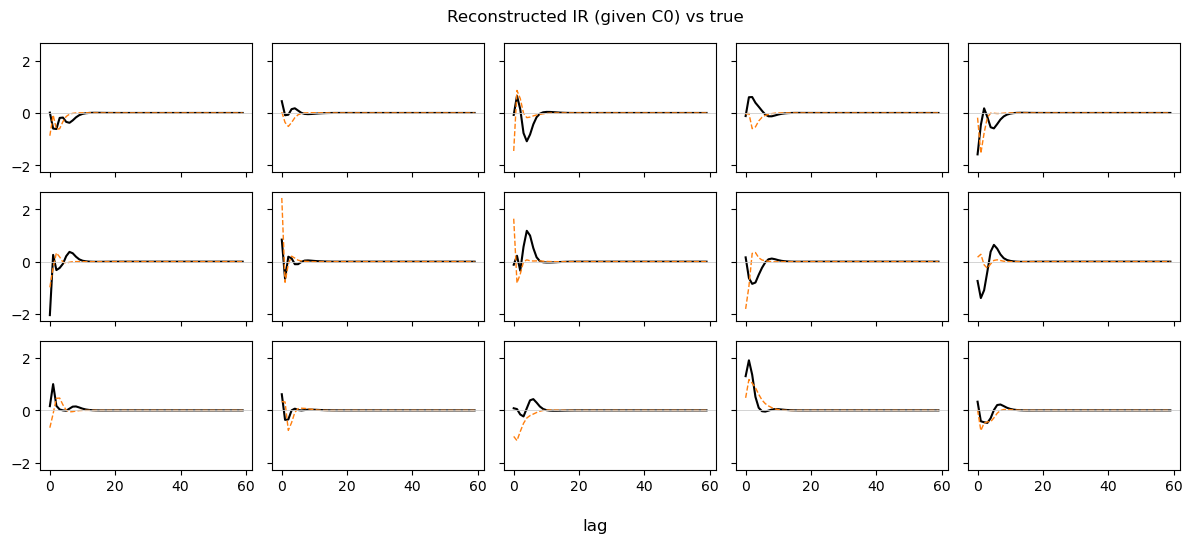

In [26]:
showr = min(60, L)
fig, axes = plt.subplots(p, q, figsize=(2.4*q, 1.8*p), sharex=True, sharey=True)
for i in range(p):
    for j in range(q):
        ax = axes[i, j]
        ax.plot(np.arange(showr), ir_true[i, j, :showr], 'k-', lw=1.5, label='true')
        ax.plot(np.arange(showr), ir_rec[i, j, :showr], 'C1--', lw=1, label='recovered')
        ax.axhline(0, color='0.8', lw=0.6)
fig.supxlabel('lag'); fig.suptitle('Reconstructed IR (given C0) vs true')
fig.tight_layout(); plt.show()

## Balanced truncation (no TIB) — does it recover the IR?

Balanced truncation reduces the state space `(A, B, C)` directly; it never names poles or null vectors. The impulse response is **realization-invariant**, so we check it by reconstructing `C_r A_r^k B_r` from BT's **own** reduced triple and comparing to `ir_true` — no `C0` reuse, no TIB, no frame issues.

- **Full order** (`r = n`): BT is a similarity transform, so the IR is reproduced **exactly** (relerr ~ machine precision) — the correctness check.
- **Reduced order** (`r < n`): the error is bounded by `2·Σσ_k` over the discarded Hankel singular values.

In [27]:
from ga.reducers.balanced_truncation import balanced_truncation

# BT on the full-order state space (A_true, B_true, C0) that generated ir_true
res = balanced_truncation(A_true, B_true, C0, order=n)
Ar, Br, Cr = res.A_r, res.B_r, res.C_r
ir_bt = np.real(np.tensordot(Cr, np.asarray(krylov_basis(Ar, Br, L)), (-1, 0)))

print(f'full-order BT (r={n}): IR relerr = '
      f'{np.linalg.norm(ir_bt - ir_true) / np.linalg.norm(ir_true):.2e}   (exact: BT is a similarity transform)')
print('A_r, B_r, C_r real?',
      not (np.iscomplexobj(Ar) or np.iscomplexobj(Br) or np.iscomplexobj(Cr)),
      ' eig(A_r) =', np.round(np.sort_complex(la.eigvals(Ar)), 3))
print('Hankel singular values =', np.round(res.hsv, 3))

full-order BT (r=10): IR relerr = 2.75e-15   (exact: BT is a similarity transform)
A_r, B_r, C_r real? True  eig(A_r) = [0.129-0.288j 0.129+0.288j 0.159-0.335j 0.159+0.335j 0.26 -0.279j
 0.26 +0.279j 0.554-0.153j 0.554+0.153j 0.597-0.204j 0.597+0.204j]
Hankel singular values = [6.008 5.295 4.095 3.195 2.938 1.974 1.215 0.739 0.617 0.299]


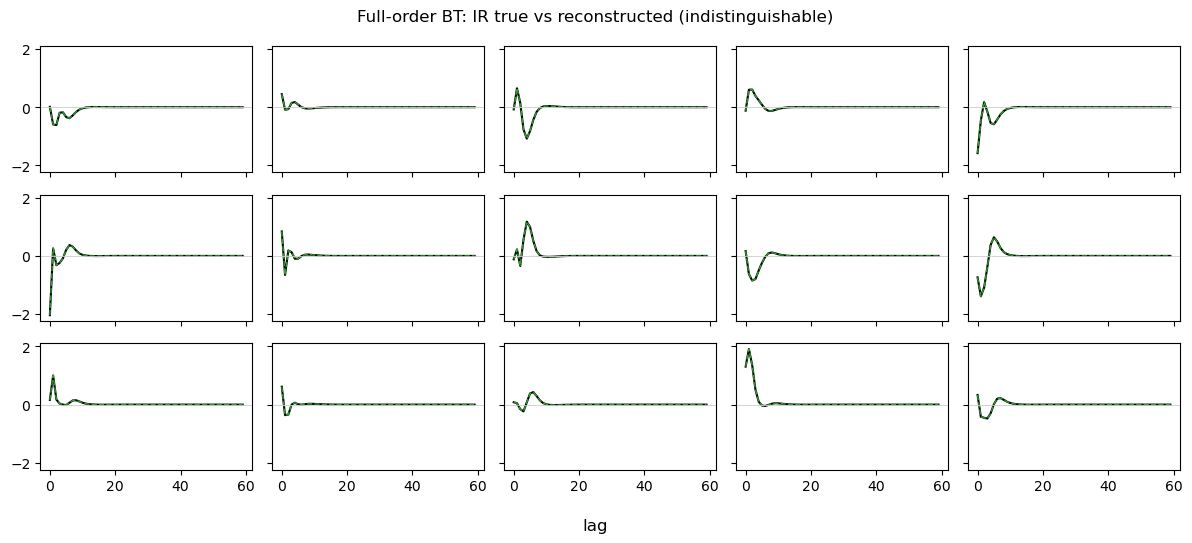

In [28]:
showb = min(60, L)
fig, axes = plt.subplots(p, q, figsize=(2.4*q, 1.8*p), sharex=True, sharey=True)
for i in range(p):
    for j in range(q):
        ax = axes[i, j]
        ax.plot(np.arange(showb), ir_true[i, j, :showb], 'k-', lw=1.5, label='true')
        ax.plot(np.arange(showb), ir_bt[i, j, :showb], 'C2--', lw=1, label='BT (full order)')
        ax.axhline(0, color='0.8', lw=0.6)
fig.supxlabel('lag'); fig.suptitle('Full-order BT: IR true vs reconstructed (indistinguishable)')
fig.tight_layout(); plt.show()

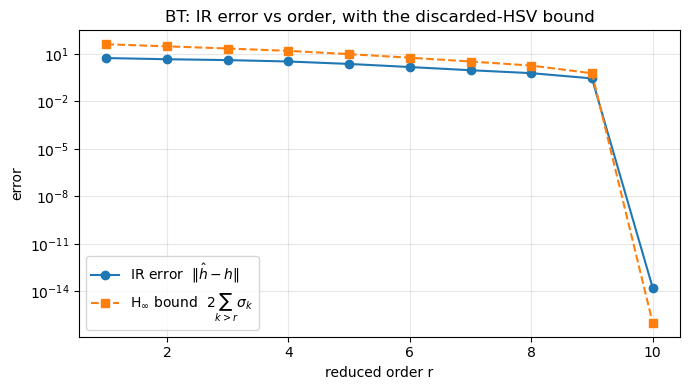

IR error stays below the 2*Sum(sigma) bound and falls to ~1e-14 at full order.


In [29]:
# reduced-order sweep: IR error vs order, with the 2*Sum(discarded HSV) bound
orders = list(range(1, n + 1)); abs_err = []; bound = []
for r in orders:
    rr = balanced_truncation(A_true, B_true, C0, order=r)
    irr = np.real(np.tensordot(rr.C_r, np.asarray(krylov_basis(rr.A_r, rr.B_r, L)), (-1, 0)))
    abs_err.append(np.linalg.norm(irr - ir_true))
    bound.append(rr.error_bound())            # 2 * sum(discarded Hankel singular values)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(orders, np.maximum(abs_err, 1e-16), 'o-', label=r'IR error  $\|\hat h - h\|$')
ax.semilogy(orders, np.maximum(bound, 1e-16), 's--', label=r'H$_\infty$ bound  $2\sum_{k>r}\sigma_k$')
ax.set_xlabel('reduced order r'); ax.set_ylabel('error')
ax.set_title('BT: IR error vs order, with the discarded-HSV bound')
ax.legend(); ax.grid(True, which='both', alpha=0.3); fig.tight_layout(); plt.show()
print('IR error stays below the 2*Sum(sigma) bound and falls to ~1e-14 at full order.')